# Batch Gradient Descent

## Concept Explanation
Batch Gradient Descent (BGD) calculates the error for each example within the training dataset, but only after all training examples have been evaluated does the model get updated. This whole process is like one epoch.

**Formula:**
$$dw = \frac{-2}{n} \sum_{i=1}^{n} (x_i \cdot (y_i - \hat{y}_i))$$
$$db = \frac{-2}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)$$

## Expected Outcome
The algorithm will compute the loss over the entire dataset before making a single parameter update. This results in a stable, smooth convergence curve. We expect the optimized line to closely match the baseline Simple Linear Regression fit.

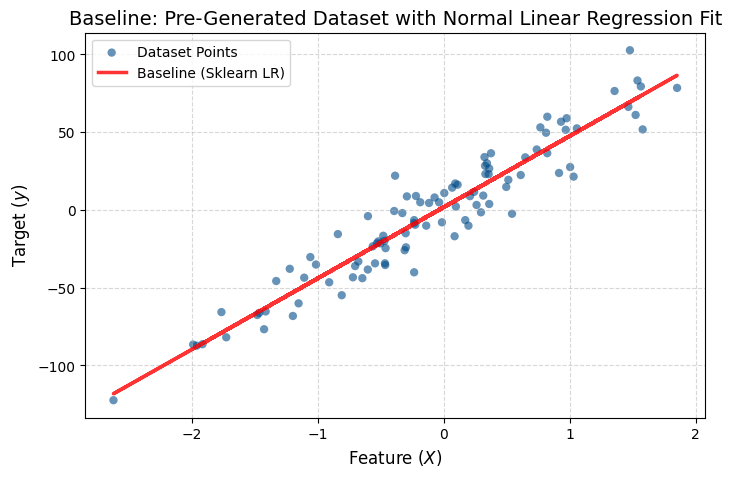

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression

# 1. Generate a synthetic dataset
# n_samples = 100 ensures enough data
# noise = 15 ensures it's more realistic than a perfect line
X, y = make_regression(n_samples=100, n_features=1, noise=15, random_state=42)
y = y.reshape(-1, 1) # Reshape for matrix operations (n, 1) instead of (n,)

# 2. Fit Simple Linear Regression (Baseline)
# Let's apply Scikit-Learn's builtin OLS Regression to have a reference line
lr = LinearRegression()
lr.fit(X, y)
y_lr_pred = lr.predict(X)

# 3. Plot Initial Data and Theoretical Line
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='#004B87', alpha=0.6, edgecolors='none', label='Dataset Points')
plt.plot(X, y_lr_pred, color='red', linewidth=2.5, alpha=0.8, label='Baseline (Sklearn LR)')
plt.title('Baseline: Pre-Generated Dataset with Normal Linear Regression Fit', fontsize=14)
plt.xlabel('Feature ($X$)', fontsize=12)
plt.ylabel('Target ($y$)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Batch Gradient Descent Implementation
We will now structure a Batch Gradient Descent from scratch. We initialize the weight and bias as zeros, calculate the predicted outputs for the *entire* dataset each epoch, find the error derivatives, and update parameters.

We'll also collect the Mean Squared Error (MSE) at each epoch to easily graph the convergence rate at the end.

--- Batch Gradient Descent Metrics ---
Execution Time: 0.00262 seconds
Final Optimized Weight: 45.7852
Final Bias: 1.7477
MSE: 175.6221
MAE: 10.6567
R2 Score: 0.9069

--- Sklearn Baseline Metrics ---
MSE: 175.6221
MAE: 10.6567
R2 Score: 0.9069



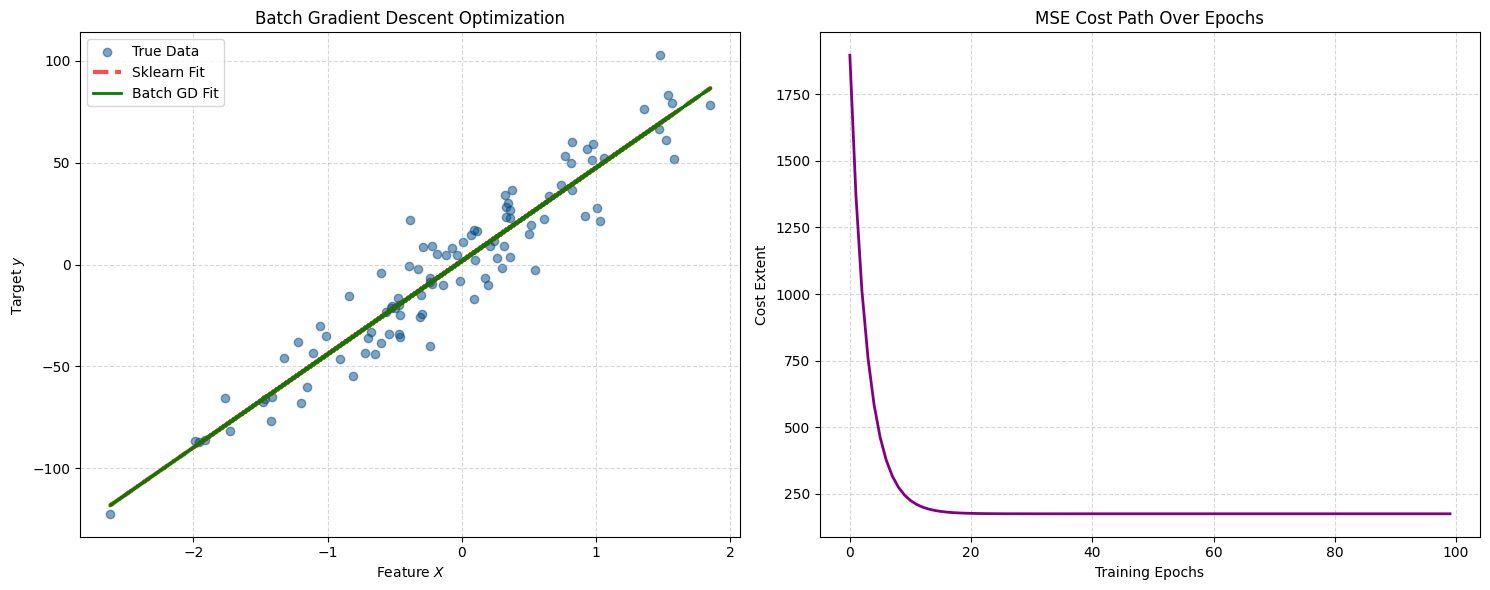

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

# Let's time how long the fitting process takes
start_time = time.time()

# 1. Initialize logic parameters
w = np.zeros((1, 1)) # Random starting weight
b = np.zeros((1, 1)) # Random starting bias
learning_rate = 0.1 
epochs = 100
n = len(X)
cost_history = [] 

# 2. Iterative loop corresponding to processing all samples at once
for epoch in range(epochs):
    # Model predictions considering entire data limits for this step
    y_pred = X.dot(w) + b
    
    # Calculate and store the MSE Cost
    cost = np.mean((y - y_pred) ** 2)
    cost_history.append(cost)
    
    # Gradients tracking the difference aggregated
    dw = (-2/n) * np.sum(X * (y - y_pred))
    db = (-2/n) * np.sum(y - y_pred)
    
    # Single scale update via batch learning rate limits
    w -= learning_rate * dw
    b -= learning_rate * db

end_time = time.time()
execution_time = end_time - start_time

final_bgd_pred = X.dot(w) + b

print(f"--- Batch Gradient Descent Metrics ---")
print(f"Execution Time: {execution_time:.5f} seconds")
print(f"Final Optimized Weight: {float(w[0][0]):.4f}")
print(f"Final Bias: {float(b[0][0]):.4f}")
print(f"MSE: {mean_squared_error(y, final_bgd_pred):.4f}")
print(f"MAE: {mean_absolute_error(y, final_bgd_pred):.4f}")
print(f"R2 Score: {r2_score(y, final_bgd_pred):.4f}\n")

print(f"--- Sklearn Baseline Metrics ---")
print(f"MSE: {mean_squared_error(y, y_lr_pred):.4f}")
print(f"MAE: {mean_absolute_error(y, y_lr_pred):.4f}")
print(f"R2 Score: {r2_score(y, y_lr_pred):.4f}\n")

# 3. Create comparative structure rendering final performance 
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

ax[0].scatter(X, y, color='#004B87', alpha=0.5, label='True Data')
ax[0].plot(X, y_lr_pred, color='red', linestyle='--', linewidth=3, alpha=0.7, label='Sklearn Fit')
ax[0].plot(X, final_bgd_pred, color='green', linewidth=2, label='Batch GD Fit')
ax[0].set_title('Batch Gradient Descent Optimization')
ax[0].set_xlabel('Feature $X$')
ax[0].set_ylabel('Target $y$')
ax[0].legend()
ax[0].grid(True, linestyle="--", alpha=0.5)

ax[1].plot(range(epochs), cost_history, color='purple', linewidth=2)
ax[1].set_title('MSE Cost Path Over Epochs')
ax[1].set_xlabel('Training Epochs')
ax[1].set_ylabel('Cost Extent')
ax[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()